# 01 · AutoScientists — Self-Organizing Agent Teams for Long-Running Scientific Experimentation

**Paper:** Gao, Fang, Zitnik (Harvard). arXiv 2605.28655 (`papers/2605.28655v1.pdf`).

**Code status:** the authors' repository (`github.com/mims-harvard/AutoScientists`) is a Claude Code prompt bundle: a bootstrap script plus ~7k lines of markdown role files that a Claude Code agent reads and improvises against. It has no LLM abstraction (cannot use OpenRouter), needs a Node coordination server, ships no tests or toy task, and has no license. Its algorithms exist only as pseudocode inside markdown. This notebook therefore **re-implements each mechanism in Python** (`notebooks/autoscientists/`), using the paper's Appendix A and the repo's role files as the specification, and drives the LLM roles through OpenRouter with the project's `.env` model.

**Toy task.** `autoscientists/task/train.py` is the "champion program" p*: an sklearn MLP on the 8×8 digits dataset with eight top-level hyperparameter constants and a stochastic validation accuracy (seed-dependent). One experiment = one edit + one training run (≈0.2 s). This gives everything the paper's mechanisms need — an editable program, numeric axes to audit, and a noisy metric — at zero cost.

| § | Building block | Paper ref | Module |
|---|---|---|---|
| 1 | Task, baseline, raw seed noise | Sec. 3.1 | `task/train.py` |
| 2 | Shared state S (champion, log, forum, queues, dead ends) + list-decide-read | Sec. 3.2, App. A.4 | `state.py` |
| 3 | Queue & claim protocol with optimistic locking | App. A.5 | `queue.py` |
| 4 | Noise-aware champion gate (eq. 1–2), lazy σ calibration | App. A.6, Alg. 3 | `gate.py` |
| 5 | Coverage audit + empirical axis priors (eq. 3), queue ranking | App. A.7 | `priors.py` |
| 6 | Analyst proposals (LLM) with ambition quota / diversity rules | Alg. 4, App. A.7 | `agents.py` |
| 7 | Experiment agent (LLM edit → train → gate → log) | Alg. 3 | `agents.py`, `heartbeat.py` |
| 8 | Discussion & self-organised roster (LLM, vote, consolidator) | Alg. 2, App. A.3 | `roster.py`, `heartbeat.py` |
| 9 | Stagnation detectors → re-discussion → team reform | Alg. 4 l.1, App. A.3 | `stagnation.py`, `roster.py` |
| 10 | Heartbeat dispatch + mini end-to-end run, ablation flags | Alg. 1, Sec. 4.5 | `heartbeat.py` |

Set `NB_QUICK=1` for smaller budgets.

In [1]:
import os, sys, json, time, random, threading
sys.path.insert(0, os.path.abspath("."))
import common
from common import md, show_source, df, QUICK, USAGE, OUTPUT_DIR
import matplotlib.pyplot as plt
from pathlib import Path
common.banner()
from autoscientists.state import SharedState, Experiment, code_hash
from autoscientists.queue import TeamQueue, StaleWrite
from autoscientists.gate import NoiseFloor, pooled_sigma, promote
from autoscientists.priors import numeric_parameters, coverage_audit, axis_priors, rank_queue
from autoscientists.stagnation import check_stagnation, no_keep_in_last, cycles_since_keep, axis_concentration
from autoscientists.roster import Discussion, validate_roster, apply_reform
from autoscientists import agents as llm
from autoscientists.heartbeat import Crew, Flags, run_train
TASK = Path("autoscientists/task/train.py"); SRC = TASK.read_text()
OUT = OUTPUT_DIR / "autoscientists"; OUT.mkdir(exist_ok=True)

Model: `deepseek/deepseek-v4-flash` via `https://openrouter.ai/api/v1` · QUICK mode: `False` · outputs → `notebooks/outputs`

## 1 · The task program p₀ and its seed noise

The paper's setting: a task, an initial program p₀, a dataset, and a metric ℓ_eval that is *stochastic* (seed-dependent). Everything downstream — especially the noise-aware gate — depends on that noise being real, so we measure it first.

In [2]:
print(SRC[:1400], "\n...")
print("numeric parameters (audit surface):", numeric_parameters(SRC))

"""Toy "champion" training script p* for the AutoScientists notebook.

Mirrors the shape of the paper's programs: a training script with top-level numeric
hyperparameters that agents edit one at a time, and a stochastic evaluation metric
(validation accuracy of an sklearn MLP on the digits dataset) that depends on --seed.
Higher is better. Runs in a few seconds on CPU.

Usage: python train.py --seed 0   -> prints a single JSON line {"metric": ..., "seed": ...}
"""
import argparse
import json
import time
import warnings

import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# ---- hyperparameters (the "numeric parameters" an analyst audits, App. A.7) ----
HIDDEN = 32          # hidden units in the single hidden layer
LR = 0.001           # initial learning rate (adam)
ALPHA = 0.0001       # L2 penalty
MAX_ITER = 30        # trainin

In [3]:
seeds = list(range(8))
metrics = [run_train(SRC, s, OUT / "runs") for s in seeds]
display(df([{"seed": s, "val_acc": m} for s, m in zip(seeds, metrics)]).T)
import statistics
print(f"mean={statistics.mean(metrics):.4f}  sd across seeds={statistics.stdev(metrics):.4f}  range={min(metrics):.3f}–{max(metrics):.3f}")

,0,1,2,3,4,5,6,7
seed,0.00,1.00,2.000000,3.000000,4.000000,5.000000,6.000000,7.00
val_acc,0.96,0.94,0.964444,0.964444,0.962222,0.946667,0.953333,0.96


mean=0.9564  sd across seeds=0.0090  range=0.940–0.964


## 2 · Shared state S

Sec. 3.2: S has four layers — the champion p* (with reproduction instructions), the experiment log L, the forum F of tagged posts, and team-local state (queues Q_k, dead-end registries D_k). App. A.4 specifies the *list-decide-read* protocol: agents first list lightweight metadata (path, version, timestamp, author) and only then fetch the items they need, so new artifact types can appear without protocol changes.

In [4]:
S = SharedState(OUT / "state_demo", champion_src=SRC, reset=True)
S.set_baseline(metrics[0], seed=0)
S.write_roster({"optim": {"axis": "optimizer schedule", "members": ["analyst-a", "gpu-1"], "hypothesis": "LR/iterations limit accuracy"},
                "capacity": {"axis": "model capacity", "members": ["analyst-b", "gpu-2"], "hypothesis": "hidden width limits accuracy"}}, author="bootstrap")
pid = S.post("[PROPOSAL]", "analyst-a", "LR up: 0.001 → 0.003", exp_id="e-demo")
S.log_experiment(Experiment("e-demo", "optim", "gpu-1", "LR", "up", "LR 0.001→0.003", metrics[0], metrics[0] + 0.004, 0.004, "NEAR-MISS", 101, 1, parent_hash=S.champion["code_hash"]))
S.add_dead_end("optim", "LR", "up", 0.003, 0.004, "inside noise band, second seed failed")
md("**list-decide-read, step 1 — metadata only:**")
display(df(S.list_items()))

**list-decide-read, step 1 — metadata only:**

,path,bytes,mtime,version,updated_by
0,champion/train.py,2170,1.788601e+09,NaN,NaN
1,champion.json,123,1.788601e+09,0.0,baseline
2,knowledge/noise_pairs.json,41,1.788601e+09,NaN,NaN
3,logs/experiments.jsonl,362,1.788601e+09,NaN,NaN
4,logs/forum.jsonl,172,1.788601e+09,NaN,NaN
5,teams/capacity/dead_ends.json,19,1.788601e+09,NaN,NaN
6,teams/capacity/queue.json,70,1.788601e+09,0.0,NaN
7,teams/optim/dead_ends.json,209,1.788601e+09,NaN,NaN
8,teams/optim/queue.json,70,1.788601e+09,0.0,NaN
9,teams/roster.json,433,1.788601e+09,1.0,bootstrap


In [5]:
md("**step 2 — read the items an agent decided it needs:**")
print("champion.json →", json.dumps(S.champion)[:200])
print("roster →", list(S.roster["teams"]))
print("forum →", S.forum(tag="[PROPOSAL]")[-1]["body"])
print("experiments.jsonl →", S.experiments()[-1]["outcome"], "| dead ends(optim) →", S.dead_ends("optim"))
print("team_of(gpu-2) →", S.team_of("gpu-2"))

**step 2 — read the items an agent decided it needs:**

champion.json → {"version": 0, "metric": 0.96, "seed": 0, "code_hash": "f818d39c77", "updated_by": "baseline", "history": []}
roster → ['optim', 'capacity']
forum → LR up: 0.001 → 0.003
experiments.jsonl → NEAR-MISS | dead ends(optim) → [{'axis': 'LR', 'direction': 'up', 'value': 0.003, 'delta': 0.004, 'reason': 'inside noise band, second seed failed', 't': 1788601229.261929}]
team_of(gpu-2) → capacity


## 3 · Queue and claim protocol (App. A.5)

> "Concurrent reads and writes are serialized by optimistic locking on a version token: a write that arrives stale is rejected and the agent retries against the latest version, so each queue update is atomic and no experiment is claimed twice."

Two agents read the same queue snapshot and both try to claim the same experiment: exactly one compare-and-swap succeeds, the other receives `StaleWrite`, re-reads, and finds the item already claimed.

In [6]:
show_source(TeamQueue.save)
q = S.queue("optim")
q.append([{"exp_id": "e1", "axis": "LR", "direction": "up", "change": "LR→0.003", "proposer": "analyst-a", "post_id": pid, "priority": 0},
          {"exp_id": "e2", "axis": "MAX_ITER", "direction": "up", "change": "MAX_ITER→60", "proposer": "analyst-a", "post_id": pid, "priority": 0}])
snap, ver = q.load()                      # both agents read the SAME snapshot/version
results = {}
def racer(agent):
    try:
        v = q.try_claim_specific("e1", agent, json.loads(json.dumps(snap)), ver); results[agent] = f"claimed e1 (queue now v{v})"
    except StaleWrite as exc:
        results[agent] = f"StaleWrite → {exc}"
barrier = threading.Barrier(2)
def go(agent):
    barrier.wait(); racer(agent)
ts = [threading.Thread(target=go, args=(a,)) for a in ("gpu-1", "gpu-2")]
[t.start() for t in ts]; [t.join() for t in ts]
for a, r in results.items(): print(f"{a}: {r}")
print("claims on disk:", q.snapshot()["claims"])
# the loser retries against the latest version and gets the next unclaimed item instead
loser = [a for a, r in results.items() if r.startswith("StaleWrite")][0]
print(f"{loser} retries → claims", q.claim(loser)["exp_id"])
q.release("e1", [a for a in results if a != loser][0], "DISCARD"); print("after release:", {k: q.snapshot()[k] for k in ("pending", "claims")}, "| completed:", [c["exp_id"] for c in q.snapshot()["completed"]])

**TeamQueue.save**

```python
    def save(self, data: dict, expected_version: int) -> int:
        """Compare-and-swap write. Returns the new version or raises StaleWrite."""
        with self._locked():
            current = json.loads(self.path.read_text())["version"]
            if current != expected_version:
                raise StaleWrite(f"queue moved from v{expected_version} to v{current}; re-read and retry")
            data["version"] = expected_version + 1
            self._write(data)
            return data["version"]

```

gpu-2: claimed e1 (queue now v2)
gpu-1: StaleWrite → queue moved from v1 to v2; re-read and retry
claims on disk: {'e1': {'agent': 'gpu-2', 't': 1788601229.2818336}}
gpu-1 retries → claims e2
after release: {'pending': [{'exp_id': 'e2', 'axis': 'MAX_ITER', 'direction': 'up', 'change': 'MAX_ITER→60', 'proposer': 'analyst-a', 'post_id': 'p3da303c0', 'priority': 0}], 'claims': {'e2': {'agent': 'gpu-1', 't': 1788601229.282731}}} | completed: ['e1']


## 4 · Noise-aware champion validation (App. A.6)

$$\text{promote}(p')=\begin{cases}\text{true} & \Delta > M\sigma\\ \text{confirm}(p',\text{seed}_2) & 0<\Delta\le M\sigma\\ \text{false} & \Delta\le 0\end{cases}\qquad \sigma=\sqrt{\tfrac{1}{2n}\sum_i(\ell_{1,i}-\ell_{2,i})^2}$$

with M = 2. σ is calibrated *lazily*: each time the middle branch fires, the pair (first run, second-seed run) of the same code is recorded; σ is estimated once n ≥ 3 pairs exist and locked at 5 pairs. Until then a conservative default is used. The cells below exercise every branch with real training runs.

In [7]:
show_source(promote)
noise = NoiseFloor(default_sigma=0.010)
champ = metrics[0]
print("champion", champ, "| default σ", noise.sigma, "→ band Mσ =", 2 * noise.sigma, "|", noise.status)

**promote**

```python
def promote(
    candidate_metric: float,
    champion_metric: float,
    noise: NoiseFloor,
    confirm: Callable[[], float] | None = None,
    M: float = M_DEFAULT,
) -> GateDecision:
    """Equation (1). ``confirm`` re-runs the candidate on a fresh seed and returns its metric.

    The middle branch records the duplicate-seed pair into ``noise`` (lazy calibration) and
    promotes only if BOTH runs strictly beat the champion.
    """
    delta = candidate_metric - champion_metric
    band = M * noise.sigma
    if delta > band:
        return GateDecision(True, "clear", delta, band, detail=f"Δ={delta:+.4f} > Mσ={band:.4f}")
    if delta <= 0:
        return GateDecision(False, "reject", delta, band, detail=f"Δ={delta:+.4f} ≤ 0")
    if confirm is None:
        return GateDecision(False, "confirm", delta, band, detail="inside noise band; no confirm() supplied")
    second = confirm()
    noise.add_pair(candidate_metric, second)
    ok = second > champion_metric  # first run already > champion (delta > 0)
    return GateDecision(
        ok, "confirm", delta, band, second_metric=second,
        detail=(f"Δ={delta:+.4f} inside band {band:.4f}; second seed {second:.4f} "
                f"{'>' if ok else '≤'} champion {champion_metric:.4f} → {'promote' if ok else 'near-miss'}"),
    )

```

champion 0.96 | default σ 0.01 → band Mσ = 0.02 | default (n=0 < 3)


In [8]:
def variant(**changes):
    src = SRC
    for k, v in changes.items():
        import re; src = re.sub(rf"^{k} = .*$", f"{k} = {v}", src, flags=re.M)
    return src
cases = {"clear win?  MAX_ITER 30→200": variant(MAX_ITER=200), "small change: HIDDEN 32→40": variant(HIDDEN=40), "harmful: LR 0.001→0.5": variant(LR=0.5)}
rows = []
for name, src in cases.items():
    m1 = run_train(src, 201, OUT / "runs")
    d = promote(m1, champ, noise, confirm=lambda: run_train(src, 202, OUT / "runs"))
    rows.append({"case": name, "metric": round(m1, 4), "Δ": round(d.delta, 4), "band Mσ": round(d.band, 4), "branch": d.branch, "2nd seed": d.second_metric, "promote": d.promote, "detail": d.detail})
display(df(rows))
print("noise pairs recorded so far:", len(noise.pairs), "|", noise.status)

,case,metric,Δ,band Mσ,branch,2nd seed,promote,detail
0,clear win? MAX_ITER 30→200,0.9689,0.0089,0.02,confirm,0.968889,True,Δ=+0.0089 inside band 0.0200; second seed 0.96...
1,small change: HIDDEN 32→40,0.9578,-0.0022,0.02,reject,NaN,False,Δ=-0.0022 ≤ 0
2,harmful: LR 0.001→0.5,0.9267,-0.0333,0.02,reject,NaN,False,Δ=-0.0333 ≤ 0


noise pairs recorded so far: 1 | default (n=1 < 3)


**Lazy calibration.** Force the middle branch a few more times with tiny perturbations so ≥3 pairs accumulate; σ switches from the default to the pooled estimate (eq. 2), then locks at 5 pairs. Compare the estimate with the naïve across-seed SD from §1: the within-pair estimate isolates seed noise *at fixed code* from code-to-code variation.

In [9]:
hist = [(len(noise.pairs), noise.sigma, noise.status)]
for i, alpha in enumerate([0.00012, 0.00009, 0.00015, 0.00011, 0.00013]):
    src = variant(ALPHA=alpha)
    m1 = run_train(src, 300 + 2 * i, OUT / "runs")
    d = promote(m1, champ, noise, confirm=lambda: run_train(src, 301 + 2 * i, OUT / "runs")) if m1 > champ else None
    if d is None:  # Δ ≤ 0 → reject branch; record a pair manually to keep the demo moving
        noise.add_pair(m1, run_train(src, 301 + 2 * i, OUT / "runs"))
    hist.append((len(noise.pairs), noise.sigma, noise.status))
display(df([{"n pairs": n, "σ": round(s, 4), "status": st} for n, s, st in hist]))
print("pairs:", [(round(a, 4), round(b, 4)) for a, b in noise.pairs])
print(f"pooled within-pair σ = {noise.sigma:.4f}  vs  across-seed SD from §1 = {statistics.stdev(metrics):.4f}")

,n pairs,σ,status
0,1,0.0100,default (n=1 < 3)
1,2,0.0100,default (n=2 < 3)
2,3,0.0020,estimated (n=3)
3,4,0.0029,estimated (n=4)
4,5,0.0034,locked (n=5)
5,6,0.0034,locked (n=6)


pairs: [(0.9689, 0.9689), (0.9622, 0.96), (0.9556, 0.96), (0.96, 0.9667), (0.96, 0.9533), (0.9556, 0.9578)]
pooled within-pair σ = 0.0034  vs  across-seed SD from §1 = 0.0090


## 5 · Analyst analytics: coverage audit and empirical axis priors (App. A.7)

$$\mu_{a,d}=\frac{1}{|E_{a,d}|}\sum_{e\in E_{a,d}}|\Delta_e|$$

The analyst (i) scans the champion for numeric parameters never varied in L (*coverage audit*), (ii) computes μ per (axis, direction), flags directions with |E| < 3 as **cold** (exploration bonus) and those with μ < σ as **below noise** (deprioritised), and (iii) sorts the team queue accordingly. Below on a synthetic log so the classification is visible; §10 does it on the real log.

In [10]:
rng = random.Random(0)
fake_log = []
def add(axis, direction, deltas, cycle=1):
    for d in deltas:
        fake_log.append({"exp_id": f"f{len(fake_log)}", "axis": axis, "direction": direction, "delta": d, "outcome": "KEEP" if d > 0.02 else "DISCARD", "cycle": cycle})
add("LR", "up", [0.031, 0.024, -0.02, 0.018]); add("LR", "down", [-0.03, -0.012, -0.041])
add("HIDDEN", "up", [0.012, 0.009, 0.015, 0.011]); add("ALPHA", "up", [0.002, -0.003, 0.001, 0.0005]); add("BATCH", "down", [0.02])
sigma = noise.sigma
cov = coverage_audit(SRC, fake_log)
print("coverage audit — never tested:", [k for k, v in cov.items() if v == 0], "| tested:", {k: v for k, v in cov.items() if v})
pri = axis_priors(fake_log, sigma, axes=list(cov))
display(df([p.__dict__ for p in pri]))

coverage audit — never tested: ['MAX_ITER', 'BETA_1', 'VAL_FRACTION', 'SCALE'] | tested: {'HIDDEN': 4, 'LR': 7, 'ALPHA': 4, 'BATCH': 1}


,axis,direction,n,mu,status,keeps
0,LR,down,3,0.027667,hot,0
1,LR,up,4,0.023250,hot,2
2,HIDDEN,up,4,0.011750,hot,0
3,BATCH,down,1,0.020000,cold,0
4,ALPHA,down,0,NaN,cold,0
5,BATCH,up,0,NaN,cold,0
6,BETA_1,down,0,NaN,cold,0
7,BETA_1,up,0,NaN,cold,0
8,HIDDEN,down,0,NaN,cold,0
9,MAX_ITER,down,0,NaN,cold,0


In [11]:
pending = [{"exp_id": f"q{i}", "axis": a, "direction": d, "change": f"{a} {d}", "priority": 0} for i, (a, d) in enumerate([("ALPHA", "up"), ("LR", "up"), ("BETA_1", "down"), ("HIDDEN", "up"), ("LR", "down")])]
print("queue before:", [(p["axis"], p["direction"]) for p in pending])
print("queue after rank_queue:", [(p["axis"], p["direction"]) for p in rank_queue(pending, pri)], "  (hot by μ → cold/exploration → below-noise last)")

queue before: [('ALPHA', 'up'), ('LR', 'up'), ('BETA_1', 'down'), ('HIDDEN', 'up'), ('LR', 'down')]
queue after rank_queue: [('LR', 'down'), ('LR', 'up'), ('HIDDEN', 'up'), ('BETA_1', 'down'), ('ALPHA', 'up')]   (hot by μ → cold/exploration → below-noise last)


## 6 · Analyst proposals — live model calls (Alg. 4, App. A.7)

Each cycle an analyst drafts **exactly two** proposals subject to the *ambition quota* (≥1 bold move, or a public `[EXEMPT]` justification), the *diversity constraints* (different axes; no third consecutive push in the same direction; nothing inside a dead-end range without saying what differs) and the *post-KEEP follow-up* rule. The prompt is adapted from the repo's `ROLE-ANALYST.md`; the rules are checked in Python after the reply.

In [12]:
print(llm.ANALYST_SYSTEM)

You are an ANALYST agent in a self-organising team of AI scientists (AutoScientists).
You never run experiments yourself. Each cycle you audit the champion program and the shared
experiment log, then propose EXACTLY TWO new experiments for your team's queue.

Rules (enforced by the harness, so follow them):
1. Each proposal changes exactly ONE research axis (one top-level hyperparameter constant, or one
   clearly named structural change) of the champion script.
2. The two proposals must target DIFFERENT axes.
3. AMBITION QUOTA: at least one proposal must be BOLD: a >=10% change of a numeric parameter that
   has already been tested, OR a never-tested axis, OR a probe that would clearly confirm or falsify
   your team's hypothesis. If neither qualifies, set "exempt_reason".
4. DIVERSITY: never propose a value inside a range already recorded in the dead-end registry unless
   you say explicitly what differs; do not repeat the same (axis, direction) as the last two
   experiments.
5. POS

In [13]:
exps = S.experiments()
proposal = llm.analyst_propose(agent="analyst-a", team="optim", hypothesis="LR/iterations limit accuracy", champion_src=SRC, champion_metric=champ,
                               priors=axis_priors(fake_log, sigma, axes=list(cov)), coverage=cov, dead_ends=S.all_dead_ends(),
                               recent_experiments=fake_log, last_keep=None, sigma=sigma)
display(df(proposal["proposals"]))
print("exempt_reason:", proposal["exempt_reason"], "| keep_followup:", proposal["keep_followup"])
print("harness flags:", [p.get("flag") for p in proposal["proposals"]])

,axis,direction,change,rationale,bold,expected_delta
0,MAX_ITER,up,Increase MAX_ITER from 30 to 60.,LR/iterations limit accuracy per team hypothes...,True,0.01
1,BATCH,down,Decrease BATCH from 64 to 32.,"Smaller batches give noisier gradients, which ...",False,0.01


exempt_reason: None | keep_followup: None
harness flags: [None, None]


## 7 · Experiment agent — live (Alg. 3)

Claim → apply ONE change to p* → train → Δ → gate → log → release claim → post `[RESULT]` / `[NEAR-MISS]`. The model only performs the edit; the diff is checked to touch a handful of lines, parse, and differ from the champion.

In [14]:
prop = proposal["proposals"][0]
new_src, diff = llm.experiment_apply(SRC, prop)
print(diff)
m1 = run_train(new_src, 401, OUT / "runs")
d = promote(m1, champ, noise, confirm=lambda: run_train(new_src, 402, OUT / "runs"))
outcome = "KEEP" if d.promote else ("NEAR-MISS" if d.branch == "confirm" else "DISCARD")
print(f"metric={m1:.4f} champion={champ:.4f} → {d.branch}: {d.detail} → {outcome}")

--- champion
+++ candidate
@@ -25 +25 @@
-MAX_ITER = 30        # training epochs
+MAX_ITER = 60        # training epochs


metric=0.9644 champion=0.9600 → confirm: Δ=+0.0044 inside band 0.0067; second seed 0.9667 > champion 0.9600 → promote → KEEP


## 8 · Discussion and self-organised team formation — live (Alg. 2, App. A.3)

Agents entering the discussion branch post candidate directions, a ranking of all directions so far with reasons, a critique of gaps, and a vote (`[DISCUSS-MORE]` / `[DISCUSS-DONE]`). When a **majority** has voted DONE, the **alphabetically-last analyst that participated** consolidates the proposals into the roster R = {(T_k, axis_k, members_k)} and writes it to S. The deterministic parts (vote tally, consolidator choice, roster validity) are in `roster.py`; the content comes from the model.

In [15]:
show_source(Discussion.consolidator)
D = Discussion("trigger-demo")
crew_agents = {"analyst-a": "analyst", "analyst-b": "analyst", "gpu-1": "experiment agent", "gpu-2": "experiment agent"}
thread = []
for rnd in (1, 2):
    for agent, role in crew_agents.items():
        r = llm.discuss(agent=agent, role=role, champion_src=SRC, champion_metric=champ, prior_posts=thread,
                        experiments_summary="no experiments yet", trigger_reason="cold-start bootstrap", round_no=rnd, max_rounds=2)
        thread.append({"author": agent, "tag": "[DISCUSSION]", "body": json.dumps({k: r[k] for k in ("directions", "ranking", "critique")})})
        D.contribute(agent, {"directions": r["directions"]}, r["vote"])
        print(f"round {rnd} {agent:10s} directions={[d['name'] for d in r['directions']]} vote={r['vote']}")
    print(f"  → majority DONE? {D.done(len(crew_agents))}")
    if D.done(len(crew_agents)): break
print("consolidator (alphabetically-last participating analyst):", D.consolidator(["analyst-a", "analyst-b"]))

**Discussion.consolidator**

```python
    def consolidator(self, analysts: list[str]) -> str | None:
        """Alphabetically-last analyst who participated (a pure tie-break, A.3)."""
        eligible = sorted(a for a in self.participants if a in analysts)
        return eligible[-1] if eligible else None

```

round 1 analyst-a  directions=['Hidden size sweep', 'Learning rate tuning', 'Regularization adjustment', 'Data scaling impact'] vote=MORE


round 1 analyst-b  directions=['Batch size variation', 'Beta1 adjustment', 'Iteration increase', 'Combined hidden and LR'] vote=DONE


round 1 gpu-1      directions=['Validation fraction tuning', 'Combined HIDDEN and MAX_ITER', 'Repeated runs with seed variation'] vote=MORE


round 1 gpu-2      directions=['Combined HIDDEN and BATCH size', 'Combined LR and MAX_ITER'] vote=MORE
  → majority DONE? False


round 2 analyst-a  directions=['Combined HIDDEN and BATCH and LR', 'Combined HIDDEN and ALPHA', 'Combined LR and BETA_1'] vote=DONE


round 2 analyst-b  directions=['Combined HIDDEN, BATCH, and LR', 'Combined HIDDEN and BATCH size', 'Hidden size sweep', 'Combined hidden and LR', 'Combined HIDDEN and MAX_ITER', 'Learning rate tuning', 'Combined LR and MAX_ITER', 'Batch size variation', 'Iteration increase', 'Regularization adjustment', 'Combined HIDDEN and ALPHA', 'Beta1 adjustment', 'Combined LR and BETA_1', 'Data scaling impact', 'Validation fraction tuning', 'Repeated runs with seed variation'] vote=DONE


round 2 gpu-1      directions=['Combined HIDDEN, BATCH, and LR', 'Hidden size sweep', 'Combined HIDDEN and BATCH size'] vote=DONE


round 2 gpu-2      directions=['Hidden size sweep', 'Combined HIDDEN, BATCH, and LR', 'Combined HIDDEN and BATCH size'] vote=DONE
  → majority DONE? True
consolidator (alphabetically-last participating analyst): analyst-b


In [16]:
roster = llm.consolidate_roster(agent=D.consolidator(["analyst-a", "analyst-b"]), posts=thread, experiment_agents=["gpu-1", "gpu-2"], analysts=["analyst-a", "analyst-b"])
display(df([{"team": k, **v} for k, v in roster["teams"].items()]))
print("validate_roster →", validate_roster(roster["teams"], ["gpu-1", "gpu-2"], ["analyst-a", "analyst-b"]) or "OK")

,team,axis,hypothesis,falsification,members
0,team-1,"HIDDEN, BATCH, LR","Increasing hidden size to 64, reducing batch s...",If validation accuracy does not improve by at ...,"[gpu-1, analyst-a]"
1,team-2,HIDDEN,Increasing hidden layer size from 32 to 64 or ...,If validation accuracy does not improve by at ...,"[gpu-2, analyst-b]"


validate_roster → OK


## 9 · Stagnation detection and team reformation

The repo carries three detectors; the paper's text uses "no improvement in the last 10 experiments". All three are pure functions of the log, and reformation applies create / merge / split / retire / rebalance operations to the roster, requiring endorsement from affected teams.

In [17]:
stalled = fake_log + [{"exp_id": f"s{i}", "axis": rng.choice(["ALPHA", "BATCH"]), "direction": "up", "delta": -0.001 * i, "outcome": "DISCARD", "cycle": 4 + i // 3} for i in range(10)]
print("no KEEP in last 10:", no_keep_in_last(stalled), "| cycles since KEEP at cycle 8:", cycles_since_keep(stalled, 8), "| axis concentration:", axis_concentration(stalled))
print("check_stagnation →", check_stagnation(stalled, current_cycle=8))
print("healthy log →", check_stagnation(fake_log, current_cycle=1))

no KEEP in last 10: True | cycles since KEEP at cycle 8: 7 | axis concentration: True
check_stagnation → ['no KEEP in last 10 experiments', '7 cycles since last KEEP', 'last 8 DISCARDs concentrated in ≤3 axes']
healthy log → ['no KEEP in last 10 experiments', 'last 8 DISCARDs concentrated in ≤3 axes']


In [18]:
teams = roster["teams"]
names = list(teams)
ops = [{"op": "merge", "teams": names[:2], "name": "merged-" + "-".join(names[:2]), "axis": "combined direction", "hypothesis": "..."}] if len(names) >= 2 else [{"op": "create", "name": "new", "axis": "x", "members": []}]
try:
    apply_reform(teams, ops)                  # no endorsement → refused
except PermissionError as e:
    print("without endorsement:", e)
reformed = apply_reform(teams, ops, endorsements={0: set(names[:2])})
print("with endorsement:", {k: v["members"] for k, v in reformed.items()})

without endorsement: op 0 (merge) lacks endorsement from ['team-1', 'team-2']
with endorsement: {'merged-team-1-team-2': ['gpu-1', 'analyst-a', 'gpu-2', 'analyst-b']}


## 10 · Heartbeat dispatch and a mini end-to-end run (Alg. 1)

Every heartbeat an agent reads R and F, then takes one of four branches: *discussion* (unresolved `[DISCUSSION-TRIGGER]` or empty roster), *no-team exit*, *resume*, or its role's *normal cycle* (Alg. 3 / Alg. 4). `Crew.run_cycles` runs the whole crew for a fixed number of heartbeats, starting from a cold start (bootstrap discussion → roster → experiments), including stagnation-triggered re-discussion.

In [19]:
show_source(Crew.heartbeat)

**Crew.heartbeat**

```python
    def heartbeat(self, agent: str) -> str:
        s = self.state
        roster = s.roster
        trigger = self._open_trigger()
        if trigger is not None or not roster["teams"]:
            if self.flags.no_self_org and roster["teams"]:
                return "no-self-org: ignoring trigger"
            return self.discussion_branch(agent, trigger)
        if s.team_of(agent) is None:
            return "no-team exit"
        if agent in self.analysts:
            return self.analyst_cycle(agent)
        return self.experiment_cycle(agent)

```

In [20]:
N_CYCLES = 3 if QUICK else 6
state = SharedState(OUT / "run", champion_src=SRC, reset=True)
state.set_baseline(run_train(SRC, 0, state.root / "runs"), seed=0)
crew = Crew(state=state, analysts=["analyst-a", "analyst-b"], experiment_agents=["gpu-1", "gpu-2", "gpu-3"],
            noise=NoiseFloor(default_sigma=0.010), max_discussion_rounds=2)
t0 = time.time()
crew.run_cycles(N_CYCLES)
print(f"\n{time.time()-t0:.0f}s; champion {state.champion['metric']:.4f} (v{state.champion['version']}) from baseline {state.champion['history'][0]['metric'] if state.champion['history'] else state.champion['metric']:.4f}")

[cycle 1] analyst-a (round 1) posted directions, voted MORE (0/5 DONE)


[cycle 1] analyst-b (round 1) posted directions, voted MORE (0/5 DONE)


[cycle 1] gpu-1 (round 1) posted directions, voted MORE (0/5 DONE)


[cycle 1] gpu-2 (round 1) posted directions, voted MORE (0/5 DONE)


[cycle 1] gpu-3 (round 1) posted directions, voted MORE (0/5 DONE)


...

[cycle 6] analyst-a queued ['BETA_1/down', 'HIDDEN/up'] on team-1


[cycle 6] analyst-b queued ['MAX_ITER/down'] on team-2


[cycle 6] gpu-1: BETA_1/down metric=0.9689 Δ=-0.0067 [reject] → DISCARD


[cycle 6] gpu-2: HIDDEN/up metric=0.9644 Δ=-0.0111 [reject] → DISCARD


[cycle 6] gpu-3: LR/down metric=0.8378 Δ=-0.1378 [reject] → DISCARD

239s; champion 0.9756 (v2) from baseline 0.9600


,cycle,team,agent,axis,direction,metric,delta,outcome,second_seed_metric
0,2,team-1,gpu-1,HIDDEN,up,0.971111,0.011111,KEEP,0.966667
1,2,team-1,gpu-2,LR,up,0.971111,0.000000,DISCARD,NaN
2,2,team-2,gpu-3,MAX_ITER,up,0.966667,-0.004444,DISCARD,NaN
3,3,team-1,gpu-1,HIDDEN,up,0.971111,0.000000,DISCARD,NaN
4,3,team-1,gpu-2,BATCH,down,0.968889,-0.002222,DISCARD,NaN
5,3,team-2,gpu-3,ALPHA,down,0.968889,-0.002222,DISCARD,NaN
6,4,team-1,gpu-1,BETA_1,down,0.975556,0.004444,KEEP,0.975556
7,4,team-1,gpu-2,VAL_FRACTION,up,0.972222,-0.003333,DISCARD,NaN
8,4,team-2,gpu-3,BATCH,up,0.973333,-0.002222,DISCARD,NaN
9,5,team-1,gpu-1,SCALE,other,0.968889,-0.006667,DISCARD,NaN


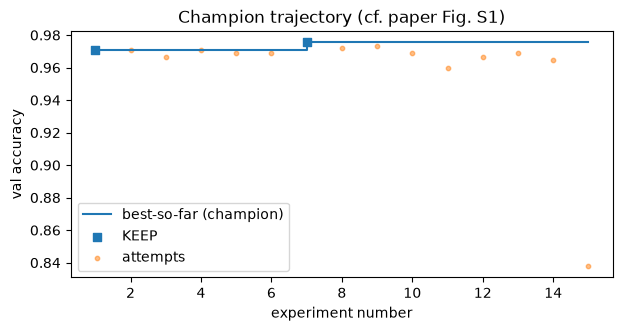

roster: {'team-1': ('ENSEMBLE, BOOTSTRAP', ['gpu-1', 'gpu-2', 'analyst-a']), 'team-2': ('PARAM, SCHEDULE', ['gpu-3', 'analyst-b'])}
forum tags: {'[DISCUSS-DONE]': 5, '[DISCUSS-MORE]': 5, '[DISCUSSION-TRIGGER]': 1, '[DISCUSSION]': 14, '[KEEP]': 2, '[PROPOSAL]': 16, '[RESULT]': 15, '[TEAM-REFORMED]': 1}
noise pairs: 2 | σ now 0.01 default (n=2 < 3)


In [21]:
exps = state.experiments()
E = df(exps)
display(E[["cycle", "team", "agent", "axis", "direction", "metric", "delta", "outcome", "second_seed_metric"]])
best = []; cur = state.champion["history"][0]["metric"] if state.champion["history"] else state.champion["metric"]
for e in exps:
    if e["outcome"] == "KEEP": cur = e["metric"]
    best.append(cur)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.step(range(1, len(best) + 1), best, where="post", label="best-so-far (champion)")
ok = [i + 1 for i, e in enumerate(exps) if e["outcome"] == "KEEP"]
ax.scatter(ok, [best[i - 1] for i in ok], marker="s", zorder=3, label="KEEP")
ax.scatter(range(1, len(exps) + 1), [e["metric"] if e["metric"] == e["metric"] else None for e in exps], s=10, alpha=0.5, label="attempts")
ax.set(xlabel="experiment number", ylabel="val accuracy", title="Champion trajectory (cf. paper Fig. S1)"); ax.legend(); plt.show()
print("roster:", {k: (v["axis"], v["members"]) for k, v in state.roster["teams"].items()})
print("forum tags:", {t: sum(p["tag"] == t for p in state.forum()) for t in sorted({p["tag"] for p in state.forum()})})
print("noise pairs:", len(state.noise_pairs()["pairs"]), "| σ now", round(crew.noise.sigma, 4), crew.noise.status)

In [22]:
md("**Axis priors and coverage computed from the real log (what the analysts saw in their last cycle):**")
display(df([p.__dict__ for p in axis_priors(exps, crew.noise.sigma, axes=list(numeric_parameters(state.champion_src)))]))
print("untested after the run:", [k for k, v in coverage_audit(state.champion_src, exps).items() if v == 0])
print("dead ends:", len(state.all_dead_ends()), "| stagnation now:", check_stagnation(exps, crew.cycle))

**Axis priors and coverage computed from the real log (what the analysts saw in their last cycle):**

,axis,direction,n,mu,status,keeps
0,LR,down,1,0.137778,cold,0
1,SCALE,down,1,0.008889,cold,0
2,SCALE,other,1,0.006667,cold,0
3,MAX_ITER,up,1,0.004444,cold,0
4,VAL_FRACTION,up,1,0.003333,cold,0
5,ALPHA,down,1,0.002222,cold,0
6,BATCH,down,1,0.002222,cold,0
7,BATCH,up,1,0.002222,cold,0
8,ALPHA,up,0,NaN,cold,0
9,BETA_1,up,0,NaN,cold,0


untested after the run: []
dead ends: 13 | stagnation now: []


### 10b · Ablations (Sec. 4.5)

`Flags` reproduce the four ablations: `no_analyst` (experiment agents propose for themselves), `no_cross_agent` (no critique / re-discussion, only own-team dead ends), `no_self_org` (roster frozen after bootstrap), `independent` (no shared state). Set `NB_ABLATIONS=1` to run them at the same budget; at this scale differences are within noise, but each flag removes exactly one mechanism.

In [23]:
if os.environ.get("NB_ABLATIONS", "0") == "1":
    res = {}
    for name, fl in {"no_analyst": Flags(no_analyst=True), "no_cross_agent": Flags(no_cross_agent=True), "no_self_org": Flags(no_self_org=True)}.items():
        st = SharedState(OUT / f"run_{name}", champion_src=SRC, reset=True); st.set_baseline(run_train(SRC, 0, st.root / "runs"), 0)
        c = Crew(state=st, analysts=["analyst-a", "analyst-b"], experiment_agents=["gpu-1", "gpu-2", "gpu-3"], noise=NoiseFloor(default_sigma=0.010), flags=fl, max_discussion_rounds=2)
        c.run_cycles(N_CYCLES); res[name] = (st.champion["metric"], len(st.experiments()), sum(e["outcome"] == "KEEP" for e in st.experiments()))
    display(df([{"variant": k, "final champion": v[0], "experiments": v[1], "KEEPs": v[2]} for k, v in {"full": (state.champion["metric"], len(exps), sum(e["outcome"] == "KEEP" for e in exps)), **res}.items()]))
else:
    print("skipped (set NB_ABLATIONS=1)")

skipped (set NB_ABLATIONS=1)


## Summary

| Block | What the run showed |
|---|---|
| Shared state + list-decide-read | four-layer S as files; metadata listing precedes content reads |
| Queue / claim | optimistic locking: one of two racing claims wins, the loser retries |
| Noise gate | all three branches of eq. (1) fire on real runs; σ moves from default → estimated → locked |
| Axis priors | μ per (axis, direction), cold / below-noise classification, queue ranking |
| Analyst (LLM) | two proposals per cycle with quota/diversity rules enforced by the harness |
| Experiment agent (LLM) | one-change edits, trained and gated against the noise floor |
| Discussion → roster (LLM) | majority DONE vote, alphabetically-last analyst consolidates a valid roster |
| Stagnation / reform | three detectors; endorsement-gated merge |
| End-to-end | cold start → teams → experiments → champion trajectory (see §10) |

In [24]:
print(USAGE.summary())

50 requests, 90418 in / 21523 out tokens, 308s in model calls, $0.0157; by tag: {'analyst': 11, 'consolidate': 4, 'discussion': 19, 'experiment': 16}
